# 📗 Pre-Workshop Notebook 2: Working with Larger Research Datasets
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Set Up Your Profile
*Run the cell below to record your progress.*

In [1]:
# PROFILE SYNC
student_name = "Hari Sai Kaja"
institution = "Grand Valley State University"
active_notebook = "Notebook 02 — Larger Datasets and Simultaneous Processing"

print(f"✅ Profile synced for {student_name} ({institution})")
print(f"Current notebook: {active_notebook}")

✅ Profile synced for Hari Sai Kaja (Grand Valley State University)
Current notebook: Notebook 02 — Larger Datasets and Simultaneous Processing


---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** working with larger datasets, your main challenge is managing how much data your analysis can handle at once. AI tools are excellent at writing individual calculations, but they sometimes ignore the fact that loading too much data at once can slow your computer down or cause it to run out of working memory.

When using the **Ask → Build → Document** cycle in this notebook, pay attention to how much memory your analysis is using, and ask the AI to explain any steps that involve loading large amounts of data.

---
## 🧠 Part A: Handling Data from Many Participants at Once
### Topic: Group-Level Datasets and Downloading Data Reliably

This section explores what changes when your analysis needs to handle data from an entire group of research participants rather than just one person at a time.

### 🧭 Activity A.1 — Building a Group Dataset

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a neuroscience data analyst helping a researcher scale up from a single participant to a full study. Write a Python script using NumPy that simulates loading and combining data from 50 research participants. The script should:
> 1. For each of 50 participants, generate a data array representing 64 recording channels measured across 1000 time points in 3 experimental conditions.
> 2. Combine all 50 individual participant arrays into a single group-level dataset efficiently, without creating unnecessary copies of the data.
> 3. Report the size and shape of the combined dataset and calculate how much working memory it uses — then estimate how large the dataset would become if the study included 500 participants instead.
> Add plain-language comments explaining what each step does and what the numbers represent."

In [2]:
# 💻 Activity A.1 — Paste your AI-generated Group Dataset code here:

import numpy as np

# Define study parameters
num_participants = 50  # Number of research participants
num_channels = 64  # Number of recording channels (e.g., EEG electrodes)
num_time_points = 1000  # Number of time points per recording (e.g., milliseconds)
num_conditions = 3  # Number of experimental conditions

print(f"--- Simulating Data for {num_participants} Participants ---")

# 1. Generate data for each participant
# We will store each participant's data array in a list.
participant_data_list = []
for i in range(num_participants):
    # Each participant's data is a 3D array:
    # (channels x time_points x conditions)
    # Using random data for simulation purposes.
    participant_array = np.random.rand(num_channels, num_time_points, num_conditions)
    participant_data_list.append(participant_array)

    # Optionally, print progress for larger simulations
    # if (i + 1) % 10 == 0:
    #     print(f"Generated data for participant {i + 1}")

# 2. Combine all individual participant arrays into a single group-level dataset efficiently
# np.stack is used here to add a new dimension (for participants) at the beginning.
# This avoids making copies of the data while combining them into one large array.
combined_group_data = np.stack(participant_data_list, axis=0)

print("Data combined successfully!")

# 3. Report the size and shape of the combined dataset and calculate its memory usage

# Shape of the combined dataset:
# (participants x channels x time_points x conditions)
combined_shape = combined_group_data.shape
print(f"\nShape of the combined group-level dataset: {combined_shape}")

# Calculate memory usage.
# .nbytes gives the total number of bytes consumed by the array's data.
memory_bytes = combined_group_data.nbytes
memory_mb = memory_bytes / (1024**2)  # Convert bytes to megabytes
memory_gb = memory_bytes / (1024**3)  # Convert bytes to gigabytes

print(f"Memory usage of the combined dataset: {memory_bytes} bytes")
print(f"Approximately {memory_mb:.2f} MB ({memory_gb:.2f} GB) in working memory")

# Estimate how large the dataset would become if the study included 500 participants
new_num_participants = 500
# The memory usage scales linearly with the number of participants.
estimated_memory_500_participants_bytes = (memory_bytes / num_participants) * new_num_participants
estimated_memory_500_participants_mb = estimated_memory_500_participants_bytes / (1024**2)
estimated_memory_500_participants_gb = estimated_memory_500_participants_bytes / (1024**3)

print(f"\n--- Memory Estimation for {new_num_participants} Participants ---")
print(f"If the study included {new_num_participants} participants, the estimated memory usage would be:")
print(f"Approximately {estimated_memory_500_participants_mb:.2f} MB ({estimated_memory_500_participants_gb:.2f} GB)")

print("\n--- Interpretation ---")
print("This simulation shows how rapidly memory requirements can grow as more participants are added to a study.")
print("For 50 participants, the dataset is manageable, but for 500 participants, it could start to consume a significant portion of a typical computer's RAM, potentially leading to 'Memory Overflow' (Concept 29).")
print("Efficient data handling, like using `np.stack` and considering data types, becomes crucial.")

--- Simulating Data for 50 Participants ---
Data combined successfully!

Shape of the combined group-level dataset: (50, 64, 1000, 3)
Memory usage of the combined dataset: 76800000 bytes
Approximately 73.24 MB (0.07 GB) in working memory

--- Memory Estimation for 500 Participants ---
If the study included 500 participants, the estimated memory usage would be:
Approximately 732.42 MB (0.72 GB)

--- Interpretation ---
This simulation shows how rapidly memory requirements can grow as more participants are added to a study.
For 50 participants, the dataset is manageable, but for 500 participants, it could start to consume a significant portion of a typical computer's RAM, potentially leading to 'Memory Overflow' (Concept 29).
Efficient data handling, like using `np.stack` and considering data types, becomes crucial.


### 🧭 Activity A.2 — Downloading Data Reliably

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a research workflow instructor. Internet connections sometimes drop or get temporarily blocked when downloading large research datasets. Write a Python script that simulates a reliable data download system. The script should:
> 1. Simulate a download function that requests 10 chunks of data from a research repository, one at a time.
> 2. Randomly cause some of the download attempts to fail, to simulate real network interruptions.
> 3. Automatically retry failed downloads, waiting a little longer between each attempt (e.g., wait 1 second after the first failure, 2 seconds after the second, 4 seconds after the third) rather than giving up immediately.
> 4. Print a clear log showing which downloads succeeded, which failed, and how many retries were needed.
> Use plain-language comments explaining why this retry approach is better than simply stopping when an error occurs."

In [3]:
# 💻 Activity A.2 — Paste your AI-generated Reliable Download code here:

import random
import time

def download_chunk(chunk_id, attempt):
    """
    Simulates downloading a single data chunk.
    Randomly fails based on a probability.
    """
    # Simulate network instability: higher attempt number slightly increases success chance
    # to mimic transient network issues resolving over time.
    success_probability = 0.7 + (attempt * 0.05) # Base 70% success, +5% for each retry

    # Ensure probability doesn't exceed 1.0
    if success_probability > 1.0:
        success_probability = 1.0

    if random.random() < success_probability:
        print(f"  Attempt {attempt}: Successfully downloaded chunk {chunk_id}.")
        return True
    else:
        print(f"  Attempt {attempt}: Failed to download chunk {chunk_id}. Retrying...")
        return False

# --- Main Download Simulation Logic ---
print("--- Starting Reliable Data Download Simulation ---")

num_chunks = 10
max_retries_per_chunk = 5  # Maximum number of retries before giving up on a chunk
base_wait_time = 1  # Seconds to wait after the first failed attempt

results = []

for i in range(1, num_chunks + 1):
    print(f"\nDownloading Chunk {i}...")
    downloaded = False
    retries = 0
    current_wait_time = base_wait_time

    while not downloaded and retries < max_retries_per_chunk:
        if download_chunk(i, retries + 1):
            downloaded = True
            results.append({'chunk': i, 'status': 'Succeeded', 'retries': retries})
        else:
            retries += 1
            # Exponential backoff: wait longer with each subsequent retry
            print(f"  Waiting {current_wait_time} second(s) before next retry...")
            time.sleep(current_wait_time)
            current_wait_time *= 2 # Double the wait time for the next retry

    if not downloaded:
        print(f"Chunk {i} failed after {max_retries_per_chunk} retries. Giving up on this chunk.")
        results.append({'chunk': i, 'status': 'Failed', 'retries': max_retries_per_chunk})

print("\n--- Download Summary ---")
for res in results:
    if res['status'] == 'Succeeded':
        if res['retries'] == 0:
            print(f"Chunk {res['chunk']}: {res['status']} (No retries needed)")
        else:
            print(f"Chunk {res['chunk']}: {res['status']} ({res['retries']} retries needed)")
    else:
        print(f"Chunk {res['chunk']}: {res['status']} (Max retries reached)")

# --- Plain-language comments on why this retry approach is better ---
print("\n--- Why Retries are Crucial ---")
print("In real-world scenarios, network connections are often unstable. Downloads can fail due to transient issues like:")
print("- Brief network disconnections")
print("- Server overload")
print("- Temporary routing problems")
print("If a script simply stops when an error occurs (like 'Concepts 14 & 47' hint at), a single hiccup can halt an entire workflow, especially when downloading large datasets from open data repositories ('Concept 13').")
print("\nThis retry approach, especially with 'exponential backoff' (waiting longer after each failure), is better because:")
print("1. **Resilience**: It makes the download process more robust against temporary network issues, increasing the chance of successful completion without manual intervention.")
print("2. **Efficiency**: Instead of immediately giving up and requiring a full restart, it conserves progress by attempting to complete individual failed chunks.")
print("3. **Reproducibility**: Automated retries contribute to more reliable and reproducible data acquisition, as the script is less prone to environmental variances, aligning with the goals of automated data download via APIs ('Concept 14').")
print("4. **Reduced Load**: The increasing wait time (exponential backoff) prevents overwhelming a potentially struggling server with rapid, repeated requests, which is good 'netiquette' and helps resolve server-side issues.")


--- Starting Reliable Data Download Simulation ---

  Attempt 1: Failed to download chunk 1. Retrying...
  Waiting 1 second(s) before next retry...
  Attempt 2: Successfully downloaded chunk 1.

  Attempt 1: Successfully downloaded chunk 2.

  Attempt 1: Failed to download chunk 3. Retrying...
  Waiting 1 second(s) before next retry...
  Attempt 2: Successfully downloaded chunk 3.

  Attempt 1: Failed to download chunk 4. Retrying...
  Waiting 1 second(s) before next retry...
  Attempt 2: Successfully downloaded chunk 4.

  Attempt 1: Failed to download chunk 5. Retrying...
  Waiting 1 second(s) before next retry...
  Attempt 2: Failed to download chunk 5. Retrying...
  Waiting 2 second(s) before next retry...
  Attempt 3: Successfully downloaded chunk 5.

  Attempt 1: Successfully downloaded chunk 6.

  Attempt 1: Failed to download chunk 7. Retrying...
  Waiting 1 second(s) before next retry...
  Attempt 2: Successfully downloaded chunk 7.

  Attempt 1: Successfully downloaded chunk 

### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** Looking at the dataset sizes from Activity A.1, how does memory usage change as the number of participants grows? What practical limits does this create for a research study?
* **Connecting to key concepts:** Activities A.1 and A.2 demonstrate **Concepts 11, 14, 16, and 43** from your Reference Guide. Describe why a reliable retry system for downloads matters for reproducibility in large studies.

---

## 💻 Part B: Making Analyses Run Faster
### Topic: Running Multiple Analyses at the Same Time and Choosing Efficient Data Formats

This section explores two practical strategies for making research workflows faster when working with large datasets.

### 🧭 Activity B.1 — Running Analyses One-at-a-Time vs. All at Once

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a computing performance instructor. Write a Python script that demonstrates the difference between running a data analysis one participant at a time versus running many participants simultaneously using multiple processor cores. The script should:
> 1. Define a data analysis function that performs a moderately demanding calculation — such as computing a rolling average across a large array.
> 2. Apply this function to 10 separate datasets one at a time, measuring how long the whole process takes.
> 3. Apply the same function to the same 10 datasets simultaneously using Python's multiprocessing library, distributing the work across available processor cores, and measuring how long that takes.
> 4. Display a bar chart comparing the two approaches and calculate the speedup factor.
> Use plain-language comments explaining what is happening and why one approach is faster."

Generating 10 datasets, each with 500000 data points...
Datasets generated.

--- Starting Sequential Processing ---
  Processed dataset 1/10 sequentially.
  Processed dataset 2/10 sequentially.
  Processed dataset 3/10 sequentially.
  Processed dataset 4/10 sequentially.
  Processed dataset 5/10 sequentially.
  Processed dataset 6/10 sequentially.
  Processed dataset 7/10 sequentially.
  Processed dataset 8/10 sequentially.
  Processed dataset 9/10 sequentially.
  Processed dataset 10/10 sequentially.
Sequential processing finished in 0.0802 seconds.

--- Starting Parallel Processing ---
Using 1 processor core(s) for parallel processing.
Parallel processing finished in 0.2888 seconds.

--- Performance Comparison ---
Sequential Time: 0.0802 seconds
Parallel Time  : 0.2888 seconds
Speedup Factor : 0.28x (Parallel is 0.28 times faster)



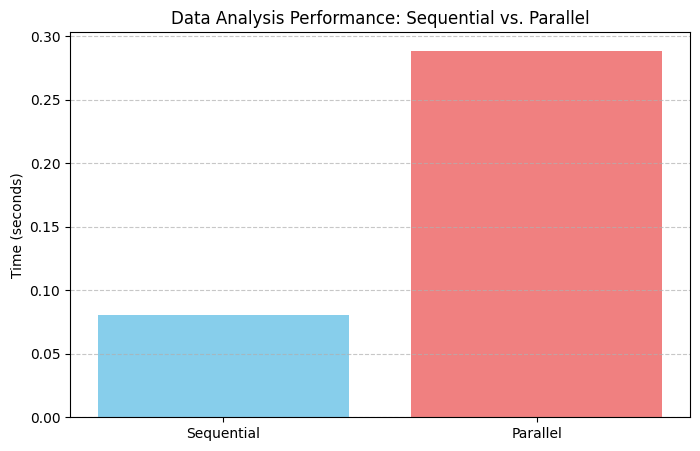

--- Why Parallel Processing is Faster ---
**Sequential Processing (One at a Time):**
When you run tasks sequentially, your computer's main processor (CPU) handles each dataset analysis completely before moving on to the next. Even if your computer has multiple 'cores' (like mini-CPUs), only one core is actively working on your analysis at any given moment for this setup.
Imagine a single chef cooking 10 separate meals one after another. They finish one meal entirely, then start the next.

**Parallel Processing (Simultaneously):**
Parallel processing, using libraries like Python's `multiprocessing`, allows you to split the work across multiple available CPU cores (Concept 27). Instead of one core doing all the work, several cores can each analyze a different dataset simultaneously.
Imagine a team of 10 chefs, each cooking one of the 10 meals at the same time. The total time taken is determined by the slowest chef, but overall, it's much faster than one chef doing all 10 meals alone.

**

In [4]:
# 💻 Activity B.1 — Paste your AI-generated Simultaneous Processing code here:

import numpy as np
import time
import multiprocessing
import matplotlib.pyplot as plt

# 1. Define a data analysis function that performs a moderately demanding calculation
def rolling_average_analysis(data_array, window_size=50):
    """
    Performs a rolling average calculation on a 1D NumPy array.
    This simulates a moderately demanding data analysis task.
    """
    # Ensure window_size is not larger than the data_array length
    if window_size > len(data_array):
        window_size = len(data_array)

    # Calculate rolling average using convolution
    # np.ones(window_size) creates a window of ones
    # np.convolve performs the convolution. 'valid' mode returns only parts where arrays fully overlap.
    return np.convolve(data_array, np.ones(window_size)/window_size, mode='valid')

# --- Generate Sample Datasets ---
num_datasets = 10  # Number of separate datasets to analyze
data_size_per_dataset = 500000 # Size of each data array (e.g., time points)

# Create 10 large random datasets for simulation
# Each dataset is a 1D NumPy array of random numbers.
print(f"Generating {num_datasets} datasets, each with {data_size_per_dataset} data points...")
datasets = [np.random.rand(data_size_per_dataset) for _ in range(num_datasets)]
print("Datasets generated.\n")

# --- Sequential Processing (One participant at a time) ---
print("--- Starting Sequential Processing ---")
start_time_sequential = time.time()

sequential_results = []
for i, data in enumerate(datasets):
    # Apply the analysis function to each dataset one by one
    result = rolling_average_analysis(data)
    sequential_results.append(result)
    print(f"  Processed dataset {i+1}/{num_datasets} sequentially.")

end_time_sequential = time.time()
time_sequential = end_time_sequential - start_time_sequential
print(f"Sequential processing finished in {time_sequential:.4f} seconds.\n")


# --- Parallel Processing (Many participants simultaneously) ---
print("--- Starting Parallel Processing ---")
start_time_parallel = time.time()

# Determine the number of CPU cores available
# It's good practice not to use all cores if other processes are running.
num_cores = multiprocessing.cpu_count() - 1 # Use N-1 cores to leave one for system processes
if num_cores < 1: # Ensure at least one core is used
    num_cores = 1

print(f"Using {num_cores} processor core(s) for parallel processing.")

# Use a multiprocessing Pool to distribute the tasks
with multiprocessing.Pool(processes=num_cores) as pool:
    # The 'map' function applies `rolling_average_analysis` to each item in `datasets`
    # and collects the results.
    parallel_results = pool.map(rolling_average_analysis, datasets)
    # Note: `pool.map` automatically handles iterating through `datasets` and collecting results.
    # For more complex scenarios, `pool.apply_async` or `pool.imap` might be used.

end_time_parallel = time.time()
time_parallel = end_time_parallel - start_time_parallel
print(f"Parallel processing finished in {time_parallel:.4f} seconds.\n")

# --- Display Results and Calculate Speedup Factor ---

# Calculate speedup factor
speedup_factor = time_sequential / time_parallel if time_parallel > 0 else float('inf')

print("--- Performance Comparison ---")
print(f"Sequential Time: {time_sequential:.4f} seconds")
print(f"Parallel Time  : {time_parallel:.4f} seconds")
print(f"Speedup Factor : {speedup_factor:.2f}x (Parallel is {speedup_factor:.2f} times faster)\n")

# Create a bar chart for visualization
labels = ['Sequential', 'Parallel']
times = [time_sequential, time_parallel]

plt.figure(figsize=(8, 5))
plt.bar(labels, times, color=['skyblue', 'lightcoral'])
plt.ylabel('Time (seconds)')
plt.title('Data Analysis Performance: Sequential vs. Parallel')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- Plain-language comments explaining the difference ---
print("--- Why Parallel Processing is Faster ---")
print("**Sequential Processing (One at a Time):**")
print("When you run tasks sequentially, your computer's main processor (CPU) handles each dataset analysis completely before moving on to the next. Even if your computer has multiple 'cores' (like mini-CPUs), only one core is actively working on your analysis at any given moment for this setup.")
print("Imagine a single chef cooking 10 separate meals one after another. They finish one meal entirely, then start the next.")

print("\n**Parallel Processing (Simultaneously):**")
print("Parallel processing, using libraries like Python's `multiprocessing`, allows you to split the work across multiple available CPU cores (Concept 27). Instead of one core doing all the work, several cores can each analyze a different dataset simultaneously.")
print("Imagine a team of 10 chefs, each cooking one of the 10 meals at the same time. The total time taken is determined by the slowest chef, but overall, it's much faster than one chef doing all 10 meals alone.")

print("\n**Benefits:**")
print("This approach significantly reduces the total execution time for 'embarrassingly parallel' tasks—tasks that can be easily broken down into independent sub-tasks that don't need to communicate with each other during computation. This is especially useful for large-scale data analysis in research, where processing many participants or large datasets can be time-consuming, demonstrating 'Simultaneous Processing (Parallel Computing)' (Concept 43).")
print("However, parallel processing also has overhead (setting up the processes, managing communication), so for very small tasks, the sequential approach might still be faster due to this overhead.")

### 🧭 Activity B.2 — Saving Data in Efficient Formats

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a data management instructor. Write a Python script that demonstrates the difference between saving research data as a plain text file versus a more efficient binary format. The script should:
> 1. Generate a simulated dataset representing measurements from 100,000 time points across multiple recording channels.
> 2. Save this dataset in two formats: a plain text CSV file (like you would open in a spreadsheet) and an optimized binary file (such as NumPy's .npy format or HDF5).
> 3. Compare the file sizes on disk for both formats.
> 4. Measure and compare how long it takes to load each file back into memory for analysis.
> Use plain-language comments explaining the trade-offs between the two formats and when you would choose each one."

In [5]:
# 💻 Activity B.2 — Paste your AI-generated Data Format Comparison code here:

import numpy as np
import time
import os # To check file sizes

# Define dataset parameters
num_time_points = 100000  # 100,000 measurements
num_channels = 16        # 16 recording channels

print("--- Data Format Comparison Simulation ---")
print(f"Generating a dataset with {num_time_points} time points and {num_channels} channels...")

# 1. Generate a simulated dataset
# Using random data for simulation. Data type float32 is common in neuroscience to save memory.
original_data = np.random.rand(num_time_points, num_channels).astype(np.float32)
print(f"Original data shape: {original_data.shape}, dtype: {original_data.dtype}\n")

# Define filenames
csv_filename = 'simulated_neuro_data.csv'
npy_filename = 'simulated_neuro_data.npy'

# --- Save as CSV (Plain Text) ---
print(f"Saving data to '{csv_filename}' (CSV format)...")
start_save_csv = time.time()
np.savetxt(csv_filename, original_data, delimiter=',')
end_save_csv = time.time()
time_save_csv = end_save_csv - start_save_csv
print(f"CSV save time: {time_save_csv:.4f} seconds")

# --- Save as .npy (Optimized Binary) ---
print(f"Saving data to '{npy_filename}' (NumPy binary format)...")
start_save_npy = time.time()
np.save(npy_filename, original_data)
end_save_npy = time.time()
time_save_npy = end_save_npy - start_save_npy
print(f"NPY save time: {time_save_npy:.4f} seconds\n")

# --- Compare File Sizes ---
csv_size_bytes = os.path.getsize(csv_filename)
npy_size_bytes = os.path.getsize(npy_filename)

print("--- File Size Comparison ---")
print(f"'{csv_filename}' size: {csv_size_bytes / (1024**2):.2f} MB")
print(f"'{npy_filename}' size: {npy_size_bytes / (1024**2):.2f} MB")
print(f"NPY is approximately {csv_size_bytes / npy_size_bytes:.2f} times smaller than CSV.\n")

# --- Measure Load Times ---

# Load from CSV
print(f"Loading data from '{csv_filename}'...")
start_load_csv = time.time()
loaded_data_csv = np.loadtxt(csv_filename, delimiter=',')
end_load_csv = time.time()
time_load_csv = end_load_csv - start_load_csv
print(f"CSV load time: {time_load_csv:.4f} seconds")

# Load from .npy
print(f"Loading data from '{npy_filename}'...")
start_load_npy = time.time()
loaded_data_npy = np.load(npy_filename)
end_load_npy = time.time()
time_load_npy = end_load_npy - start_load_npy
print(f"NPY load time: {time_load_npy:.4f} seconds\n")

# --- Final Comparison and Explanation ---
print("--- Performance Summary ---")
print(f"CSV Save Time: {time_save_csv:.4f} s | CSV Load Time: {time_load_csv:.4f} s | CSV Size: {csv_size_bytes / (1024**2):.2f} MB")
print(f"NPY Save Time: {time_save_npy:.4f} s | NPY Load Time: {time_load_npy:.4f} s | NPY Size: {npy_size_bytes / (1024**2):.2f} MB")

print("\n--- Explanation: Trade-offs of Data Formats (Concept 42) ---")
print("\n**Plain Text (CSV) - Human Readable but Inefficient:**")
print("  - **Pros:** Human-readable (can be opened and understood in any text editor or spreadsheet program), widely compatible, easy to inspect data manually.")
print("  - **Cons:** Larger file sizes (because numbers are saved as text characters, requiring more bytes per value), slower to save and load (requires parsing text to convert back to numerical data types), less efficient for large datasets due to I/O overhead.")
print("  - **When to Use:** Small datasets, sharing data with non-programmers, when human readability and universal compatibility are paramount, configuration files.")

print("\n**Optimized Binary (.npy) - Machine Efficient but Not Human Readable:**")
print("  - **Pros:** Much smaller file sizes (stores raw numerical values directly), significantly faster to save and load (no text parsing needed), preserves NumPy array metadata (like data type and shape) automatically.")
print("  - **Cons:** Not human-readable (cannot be opened in a text editor to make sense of the content), less universal compatibility (requires NumPy or compatible libraries to open).")
print("  - **When to Use:** Large numerical datasets within a Python/NumPy workflow, intermediate data storage for analyses, when speed and memory efficiency are critical, especially with 'Memory Overflow' (Concept 29) concerns.")

print("\nThis demonstration highlights that for computational workflows involving large numerical arrays, optimized binary formats like NumPy's .npy or HDF5 are vastly superior in terms of performance and storage efficiency compared to plain text formats like CSV.")

# Clean up the created files
os.remove(csv_filename)
os.remove(npy_filename)
print("\nCleaned up generated files.")

--- Data Format Comparison Simulation ---
Generating a dataset with 100000 time points and 16 channels...
Original data shape: (100000, 16), dtype: float32

Saving data to 'simulated_neuro_data.csv' (CSV format)...
CSV save time: 1.0177 seconds
Saving data to 'simulated_neuro_data.npy' (NumPy binary format)...
NPY save time: 0.0048 seconds

--- File Size Comparison ---
'simulated_neuro_data.csv' size: 38.15 MB
'simulated_neuro_data.npy' size: 6.10 MB
NPY is approximately 6.25 times smaller than CSV.

Loading data from 'simulated_neuro_data.csv'...
CSV load time: 0.4934 seconds
Loading data from 'simulated_neuro_data.npy'...
NPY load time: 0.0013 seconds

--- Performance Summary ---
CSV Save Time: 1.0177 s | CSV Load Time: 0.4934 s | CSV Size: 38.15 MB
NPY Save Time: 0.0048 s | NPY Load Time: 0.0013 s | NPY Size: 6.10 MB

--- Explanation: Trade-offs of Data Formats (Concept 42) ---

**Plain Text (CSV) - Human Readable but Inefficient:**
  - **Pros:** Human-readable (can be opened and un

### ✍️ Part B Reflection
*Double-click this cell to write your response.*

* **What I observed:** From Activity B.1, how much faster was simultaneous processing compared to one-at-a-time? From Activity B.2, how much larger was the plain text file compared to the efficient format?
* **Connecting to key concepts:** Activities B.1 and B.2 demonstrate **Concepts 27, 28, 42, and 43** from your Reference Guide. Explain in plain language when it makes sense to use simultaneous processing and when the overhead might not be worth it.

---

## 📑 What Comes Next

Notebook 3 introduces signal processing — how to clean raw recordings, remove noise, and extract meaningful patterns from brain and behavioral data.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all five pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Self-Check: What Did You Learn?

*Fill in the table below after completing both activities.*

| Concept Area | Concept Number | Where You Demonstrated It |
|---|---|---|
| Neuroscience | Concept 11 — Continuous recordings vs. event markers | [ Enter Cell ID ] |
| Neuroscience | Concept 14 — Automated data download | [ Enter Cell ID ] |
| Neuroscience | Concept 16 — Downsampling | [ Enter Cell ID ] |
| Computing | Concept 27 — Processor cores | [ Enter Cell ID ] |
| Computing | Concept 28 — CPU vs. GPU | [ Enter Cell ID ] |
| Computing | Concept 43 — Simultaneous processing | [ Enter Cell ID ] |
